<a href="https://colab.research.google.com/github/krushna1133/NNDL-Practical/blob/main/NNDL_Practical3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy


Train data shape:  (60000, 28, 28)
Train data shape:  (60000,)
Train data shape:  (10000, 28, 28)
Train data shape:  (10000, 28, 28)


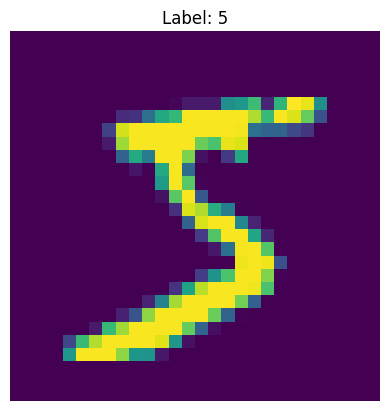

In [48]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print("Train data shape: ", x_train.shape)
print("Train data shape: ", y_train.shape)
print("Train data shape: ", x_test.shape)
print("Train data shape: ", x_test.shape)

plt.imshow(x_train[0])
plt.title("Label: " + str(y_train[0]))
plt.axis('off')
plt.show()

In [32]:
x_train, x_test = x_train/255.0, x_test/255.0
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [33]:
model.compile(optimizer=Adam(),
              loss=SparseCategoricalCrossentropy(),
              metrics=[SparseCategoricalAccuracy()])

In [66]:
history = model.fit(x_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0801 - sparse_categorical_accuracy: 0.9789
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0787 - sparse_categorical_accuracy: 0.9796
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0721 - sparse_categorical_accuracy: 0.9809
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0729 - sparse_categorical_accuracy: 0.9815
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0687 - sparse_categorical_accuracy: 0.9825
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0647 - sparse_categorical_accuracy: 0.9833
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0581 - sparse_categorical_accuracy: 0.9854
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0659 - sparse_categorical_accuracy: 0.9844
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0629 - sparse_categorical_accuracy: 0.9848
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━

In [53]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'\nTest accuracy: {test_acc}')


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1602 - sparse_categorical_accuracy: 0.9637

Test accuracy: 0.963699996471405


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


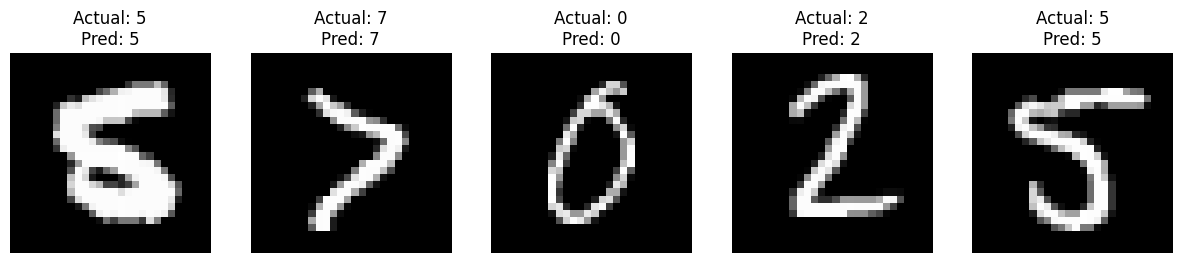

In [67]:
predict = model.predict(x_test)
num_images = 5
random_ind = np.random.choice(len(x_test), num_images, replace=False)

plt.figure(figsize=(15,6))

for i, idx in enumerate(random_ind):
    plt.subplot(1, num_images, i+1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.axis('off')

    pred_label = np.argmax(predict[idx])

    plt.title(f"Actual: {y_test[idx]}\nPred: {pred_label}")

plt.show()

In [ ]:
from IPython.core import history
plt.figure(figsize=(15,6))
plt.figure(1,2,1)